In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)


In [23]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'difficulty'
]

dataset = pd.read_csv("KDDTrain+.txt", names=columns)

print(dataset.head())
print(dataset.shape)


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [24]:
for col in reversed(dataset.columns):
    if dataset[col].dtype == 'object':
        attack_col = col
        break

dataset.rename(columns={attack_col: 'attack'}, inplace=True)

print("Attack Distribution:")
print(dataset['attack'].value_counts())


Attack Distribution:
attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


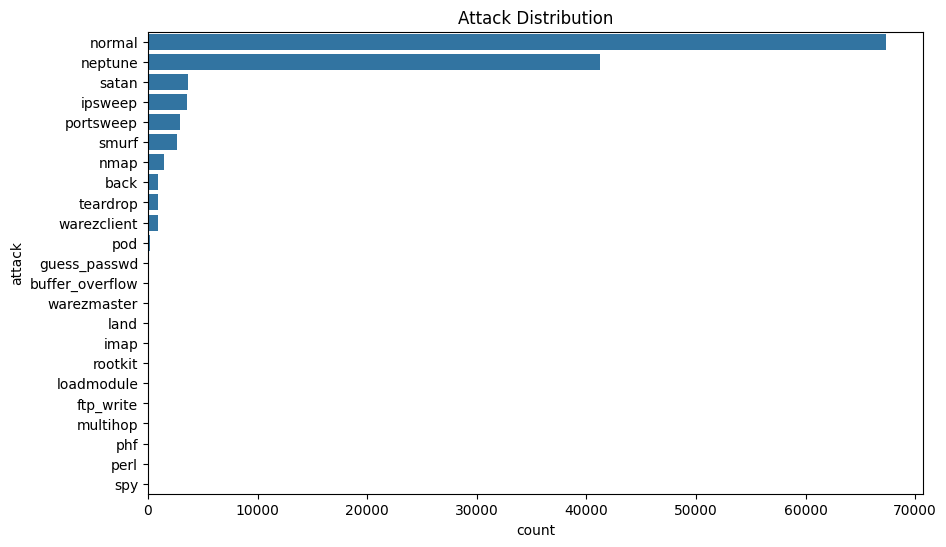

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(y='attack', data=dataset,
              order=dataset['attack'].value_counts().index)
plt.title("Attack Distribution")
plt.show()


In [26]:
categorical_features = dataset.select_dtypes(include=['object']).columns
categorical_features = categorical_features.drop('attack')

le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col])
    le_dict[col] = le

label_encoder = LabelEncoder()
dataset['attack'] = label_encoder.fit_transform(dataset['attack'])

dataset.fillna(0, inplace=True)


In [27]:
numerical_features = dataset.select_dtypes(include=['int64','float64']).columns
numerical_features = numerical_features.drop('attack')

scaler = StandardScaler()
dataset[numerical_features] = scaler.fit_transform(dataset[numerical_features])


In [28]:
X = dataset.drop('attack', axis=1)
y = dataset['attack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (100778, 42)
Test Shape: (25195, 42)


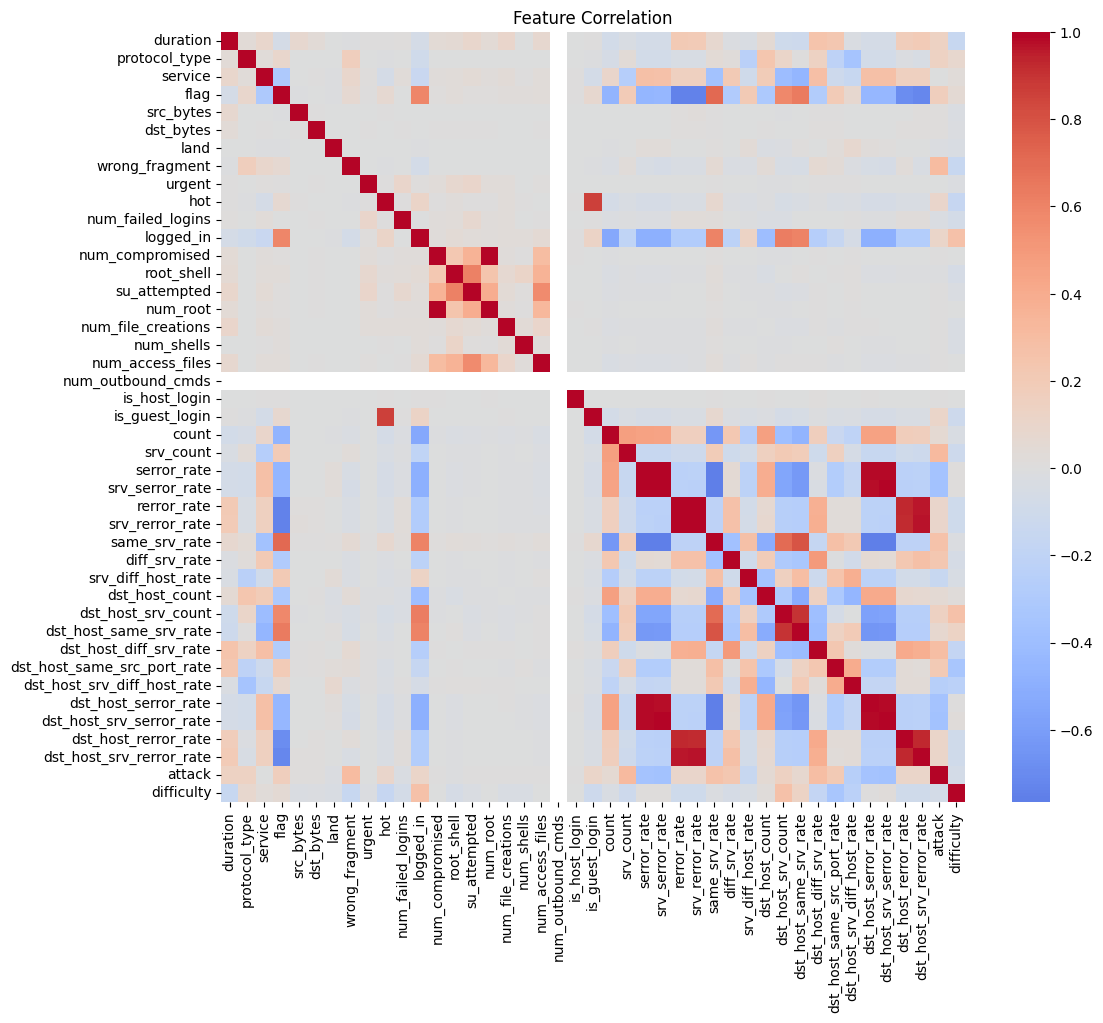

In [29]:
plt.figure(figsize=(12,10))
sns.heatmap(dataset.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation")
plt.show()


In [30]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9969041476483429


In [31]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.9984917642389363


In [32]:
svm_model = SVC(random_state=42, probability=True)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.9953562214725143



Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.33      0.50         9
           2       0.00      0.00      0.00         0
           3       1.00      0.73      0.84        11
           4       0.50      1.00      0.67         1
           5       0.99      0.99      0.99       733
           6       1.00      0.33      0.50         3
           7       0.00      0.00      0.00         0
           9       1.00      1.00      1.00      8228
          10       0.97      0.99      0.98       313
          11       1.00      1.00      1.00     13422
          12       1.00      1.00      1.00         1
          13       0.00      0.00      0.00         1
          14       1.00      0.93      0.96        43
          15       0.99      0.99      0.99       573
          16       0.00      0.00      0.00         1
          17       0.99      0.99      0.99       738
     

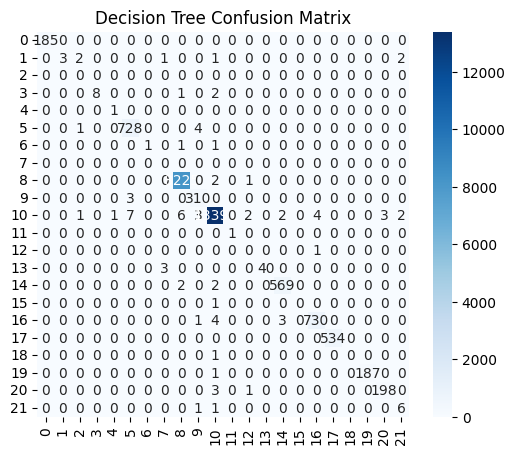


Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.33      0.50         9
           2       0.00      0.00      0.00         0
           3       1.00      0.82      0.90        11
           4       1.00      1.00      1.00         1
           5       0.99      0.99      0.99       733
           6       1.00      0.33      0.50         3
           7       0.00      0.00      0.00         0
           9       1.00      1.00      1.00      8228
          10       0.99      0.99      0.99       313
          11       1.00      1.00      1.00     13422
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      0.93      0.96        43
          15       1.00      0.99      1.00       573
          16       0.00      0.00      0.00         1
          17       1.00      0.99      1.00       738
     

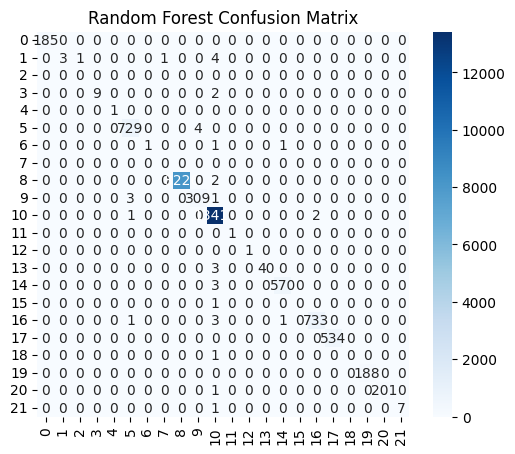


SVM Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       185
           1       1.00      0.33      0.50         9
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         1
           5       0.96      0.99      0.97       733
           6       1.00      0.67      0.80         3
           9       1.00      1.00      1.00      8228
          10       0.95      0.98      0.97       313
          11       1.00      1.00      1.00     13422
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      0.93      0.96        43
          15       0.99      0.99      0.99       573
          16       0.00      0.00      0.00         1
          17       0.99      0.99      0.99       738
          18       0.98      0.99      0.99       534
          19       0.00      0.00      0.00         1
          20   

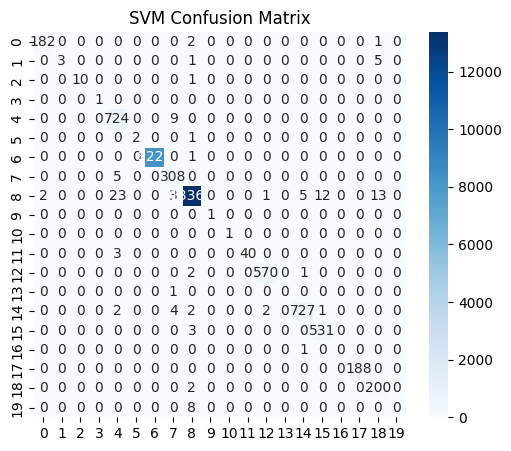

In [33]:
models = {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm
}

for name, pred in models.items():

    print(f"\n{name} Report")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()


In [34]:
param_grid = {
    'n_estimators': [50,100,150],
    'max_depth': [10,20,30],
    'min_samples_split': [2,5,10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Tuned RF Accuracy:",
      accuracy_score(y_test, y_pred_best_rf))


Fitting 3 folds for each of 27 candidates, totalling 81 fits


c:\Users\bijoy\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Tuned RF Accuracy: 0.9984917642389363


In [35]:
nn_model = Sequential()

nn_model.add(Dense(64,
                   input_dim=X_train.shape[1],
                   activation='relu'))

nn_model.add(Dropout(0.3))

nn_model.add(Dense(32,
                   activation='relu'))

nn_model.add(Dense(len(np.unique(y)),
                   activation='softmax'))

nn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


c:\Users\bijoy\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
history = nn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9506 - loss: 0.2162 - val_accuracy: 0.9911 - val_loss: 0.0429
Epoch 2/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9874 - loss: 0.0489 - val_accuracy: 0.9929 - val_loss: 0.0275
Epoch 3/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9905 - loss: 0.0358 - val_accuracy: 0.9938 - val_loss: 0.0215
Epoch 4/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9919 - loss: 0.0281 - val_accuracy: 0.9945 - val_loss: 0.0215
Epoch 5/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9926 - loss: 0.0260 - val_accuracy: 0.9947 - val_loss: 0.0191
Epoch 6/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9934 - loss: 0.0229 - val_accuracy: 0.9956 - val_loss: 0.0168
Epoch 7/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9937 - loss: 0.0218 - val_accuracy: 0.9958 - val_loss: 0.0157
Epoch 8/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9943 - loss: 0.0189 - 

In [37]:
nn_eval = nn_model.evaluate(X_test, y_test)

print("Neural Network Accuracy:",
      nn_eval[1])


788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9969 - loss: 0.0180
Neural Network Accuracy: 0.9969041347503662


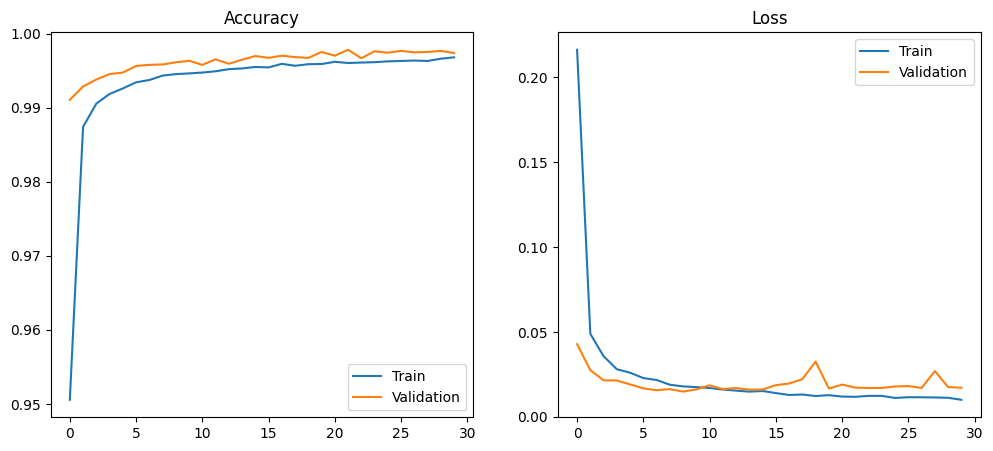

In [38]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()


In [39]:
def detect_attack(sample):

    sample_df = pd.DataFrame([sample],
                             columns=X.columns)

    for col in categorical_features:
        if col in sample_df.columns:
            le_col = le_dict[col]
            val = sample_df[col][0]

            if val in le_col.classes_:
                sample_df[col] = le_col.transform([val])
            else:
                sample_df[col] = 0

    sample_df[numerical_features] = scaler.transform(
        sample_df[numerical_features]
    )

    pred = best_rf.predict(sample_df)[0]

    confidence = max(
        best_rf.predict_proba(sample_df)[0]
    )

    attack_name = label_encoder.inverse_transform([pred])[0]

    return {
        "Traffic Status":
        "Malicious" if pred != 0 else "Normal",

        "Attack Type":
        attack_name,

        "Confidence":
        confidence
    }


In [40]:
sample_input = X_test.iloc[0].to_dict()

detection = detect_attack(sample_input)

print(detection)


{'Traffic Status': 'Malicious', 'Attack Type': 'ipsweep', 'Confidence': np.float64(0.5098333333333334)}


In [41]:
import joblib

joblib.dump(best_rf, "best_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_dict, "label_encoders.pkl")
joblib.dump(label_encoder, "attack_encoder.pkl")

print("All files saved successfully.")


All files saved successfully.
